In [1]:
import numpy as np
import os
from PIL import Image
import argparse

# Define the class information
CLASS_INFO = {
    0: {"name": "background", "rgb": [0, 0, 0]},
    1: {"name": "airplane", "rgb": [166, 202, 240]},
    2: {"name": "bare soil", "rgb": [128, 128, 0]},
    3: {"name": "buildings", "rgb": [0, 0, 128]},
    4: {"name": "cars", "rgb": [255, 0, 0]},
    5: {"name": "chaparral", "rgb": [0, 128, 0]},
    6: {"name": "court", "rgb": [128, 0, 0]},
    7: {"name": "dock", "rgb": [255, 233, 233]},
    8: {"name": "field", "rgb": [160, 160, 164]},
    9: {"name": "grass", "rgb": [0, 128, 128]},
    10: {"name": "mobile home", "rgb": [90, 87, 255]},
    11: {"name": "pavement", "rgb": [255, 255, 0]},
    12: {"name": "sand", "rgb": [255, 192, 0]},
    13: {"name": "sea", "rgb": [0, 0, 255]},
    14: {"name": "ship", "rgb": [255, 0, 192]},
    15: {"name": "tanks", "rgb": [128, 0, 128]},
    16: {"name": "trees", "rgb": [0, 255, 0]},
    17: {"name": "water", "rgb": [0, 255, 255]}
}

# Create a lookup table for fast conversion
max_val = 256
lookup_table = np.zeros((max_val, max_val, max_val), dtype=np.uint8)

# Fill the lookup table with class indices
for class_idx, class_info in CLASS_INFO.items():
    r, g, b = class_info["rgb"]
    lookup_table[r, g, b] = class_idx

def rgb_to_one_channel(rgb_mask):
    """
    Convert RGB mask to 1-channel mask with class indices.
    
    Args:
        rgb_mask: numpy array of shape (H, W, 3) with RGB values
        
    Returns:
        one_channel_mask: numpy array of shape (H, W) with class indices
    """
    # Check if image is already 1-channel (grayscale)
    if len(rgb_mask.shape) == 2:
        print(f"  Warning: Image is already 1-channel (grayscale). Shape: {rgb_mask.shape}")
        return rgb_mask
    
    # Check if it's RGBA (4 channels)
    if rgb_mask.shape[2] == 4:
        print(f"  Warning: Image has 4 channels (RGBA). Converting to RGB.")
        rgb_mask = rgb_mask[:, :, :3]  # Keep only RGB
    
    # Extract RGB channels for 3-channel images
    if len(rgb_mask.shape) == 3 and rgb_mask.shape[2] == 3:
        r = rgb_mask[:, :, 0]
        g = rgb_mask[:, :, 1]
        b = rgb_mask[:, :, 2]
        
        # Use the lookup table to convert RGB to class indices
        return lookup_table[r, g, b]
    else:
        print(f"  Warning: Unexpected image shape {rgb_mask.shape}. Returning as-is.")
        return rgb_mask

def one_channel_to_rgb(one_channel_mask):
    """
    Convert 1-channel mask back to RGB for visualization.
    
    Args:
        one_channel_mask: numpy array of shape (H, W) with class indices
        
    Returns:
        rgb_mask: numpy array of shape (H, W, 3) with RGB values
    """
    h, w = one_channel_mask.shape
    rgb_mask = np.zeros((h, w, 3), dtype=np.uint8)
    
    for class_idx in CLASS_INFO:
        mask = one_channel_mask == class_idx
        rgb_mask[mask] = CLASS_INFO[class_idx]["rgb"]
    
    return rgb_mask

def process_masks(input_folder, output_folder):
    """
    Convert all RGB masks in input_folder to 1-channel masks and save to output_folder.
    
    Args:
        input_folder: path to folder containing RGB masks
        output_folder: path to folder where 1-channel masks will be saved
    """
    # Create output folder if it doesn't exist
    os.makedirs(output_folder, exist_ok=True)
    
    # Get all image files in input folder
    supported_formats = ('.png', '.jpg', '.jpeg', '.bmp', '.tiff')
    image_files = [f for f in os.listdir(input_folder) 
                  if f.lower().endswith(supported_formats)]
    
    print(f"Found {len(image_files)} masks to process in {input_folder}")
    
    # Process each image
    for i, filename in enumerate(image_files):
        try:
            # Load mask
            rgb_path = os.path.join(input_folder, filename)
            with Image.open(rgb_path) as img:
                rgb_mask = np.array(img)
            
            print(f"Processing {filename}: shape={rgb_mask.shape}, dtype={rgb_mask.dtype}")
            
            # Convert to 1-channel
            one_channel_mask = rgb_to_one_channel(rgb_mask)
            
            # Save as PNG (preserves single channel data)
            name, ext = os.path.splitext(filename)
            output_path = os.path.join(output_folder, f"{name}.png")
            
            # Save as PNG with 8-bit depth
            Image.fromarray(one_channel_mask).save(output_path)
            
            if (i + 1) % 10 == 0 or (i + 1) == len(image_files):
                print(f"Processed {i+1}/{len(image_files)}: {filename} -> {output_path}")
                
        except Exception as e:
            print(f"❌ Error processing {filename}: {str(e)}")
            continue
    
    print(f"All masks converted and saved to {output_folder}")

def verify_conversion(input_folder, output_folder):
    """
    Verify that the conversion was correct by checking a few samples.
    """
    # Get a few files to verify
    sample_files = [f for f in os.listdir(input_folder) if f.endswith('.png')][:3]
    
    for filename in sample_files:
        try:
            # Load original mask
            rgb_path = os.path.join(input_folder, filename)
            original_mask = np.array(Image.open(rgb_path))
            
            # Load converted 1-channel mask
            name, ext = os.path.splitext(filename)
            one_channel_path = os.path.join(output_folder, f"{name}.png")
            one_channel_mask = np.array(Image.open(one_channel_path))
            
            print(f"Verification for {filename}:")
            print(f"  Original shape: {original_mask.shape}, Converted shape: {one_channel_mask.shape}")
            print(f"  Original unique values: {np.unique(original_mask)}")
            print(f"  Converted unique values: {np.unique(one_channel_mask)}")
            
        except Exception as e:
            print(f"Error verifying {filename}: {str(e)}")

def main():
    """Main function with predefined paths"""
    # Define your paths here
    input_folder = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/merged_dataset/masks'  # CHANGE THIS to your RGB masks folder
    output_folder = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/merged_dataset/1cmask'  # CHANGE THIS to your output folder
    
    # Check if input folder exists
    if not os.path.exists(input_folder):
        print(f"Error: Input folder '{input_folder}' does not exist!")
        return
    
    # Process all masks
    print("Starting mask conversion...")
    process_masks(input_folder, output_folder)
    
    # Verify conversion
    print("\nVerifying conversion...")
    verify_conversion(input_folder, output_folder)
    
    print("\nConversion completed successfully!")

if __name__ == "__main__":
    main()

Starting mask conversion...
Found 884 masks to process in /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/merged_dataset/masks
Processing 251.png: shape=(256, 256, 3), dtype=uint8
Processing runwa_1890.png: shape=(256, 256, 3), dtype=uint8
Processing 542.png: shape=(256, 256, 3), dtype=uint8
Processing 8.png: shape=(256, 256, 3), dtype=uint8
Processing 233.png: shape=(256, 256, 3), dtype=uint8
Processing 611.png: shape=(256, 256, 3), dtype=uint8
Processing 302.png: shape=(256, 256, 3), dtype=uint8
Processing stora_571.png: shape=(256, 256, 3), dtype=uint8
Processing 73.png: shape=(256, 256, 3), dtype=uint8
Processing runwa_1849.png: shape=(256, 256, 3), dtype=uint8
Processed 10/884: runwa_1849.png -> /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/merged_dataset/1cmask/runwa_1849.png
Processing 424.png: shape=(256, 256, 3), dtype=uint8
Processing 103.png: shape=(256, 256, 3), dtype=uint8
Processing beach_1185.png: shape=(256, 256, 3), dtype=uint8
Processing 247.png: shape=(256, 2

Number of classes: 18
=== ANALYZING GROUND TRUTH MASKS ===
251.png: Unique class IDs: [ 4  9 11 16]
runwa_1890.png: Unique class IDs: [ 9 11 12]
542.png: Unique class IDs: [ 2  3  9 11 16]
8.png: Unique class IDs: [8]
233.png: Unique class IDs: [16]
611.png: Unique class IDs: [ 3  6 11]
302.png: Unique class IDs: [ 7 14 17]
stora_571.png: Unique class IDs: [ 2  3  4  5  6  9 11 15 16]
73.png: Unique class IDs: [2 3 9]
runwa_1849.png: Unique class IDs: [ 6  9 11]

All unique class IDs found: [2, 3, 4, 5, 6, 7, 8, 9, 11, 12, 14, 15, 16, 17]
Number of classes in data: 14
Loading SAM model...


/home/iiitdmk-param/AMB/Proposed_3/SAM/segment-anything-main/segment_anything/build_sam.py:105: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(f)


Model created with 18 classes
Training on 707 samples, validating on 177 samples
Starting training...


/home/iiitdmk-param/.local/lib/python3.8/site-packages/torch/optim/lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1, Batch 0, Loss: 2.7945
Epoch 1, Batch 10, Loss: 3.0446
Epoch 1, Batch 20, Loss: 2.4793
Epoch 1, Batch 30, Loss: 2.0141
Epoch 1, Batch 40, Loss: 1.9825
Epoch 1, Batch 50, Loss: 1.5472
Epoch 1, Batch 60, Loss: 1.6940
Epoch 1, Batch 70, Loss: 1.8951
Epoch 1, Batch 80, Loss: 2.3623
Epoch 1, Batch 90, Loss: 1.6025
Epoch 1, Batch 100, Loss: 2.0607
Epoch 1, Batch 110, Loss: 1.4197
Epoch 1, Batch 120, Loss: 1.4587
Epoch 1, Batch 130, Loss: 1.6915
Epoch 1, Batch 140, Loss: 2.0525
Epoch 1, Batch 150, Loss: 1.3174
Epoch 1, Batch 160, Loss: 1.8366
Epoch 1, Batch 170, Loss: 1.8888
Epoch 1, Batch 180, Loss: 1.4663
Epoch 1, Batch 190, Loss: 2.3264
Epoch 1, Batch 200, Loss: 1.1285
Epoch 1, Batch 210, Loss: 1.2350
Epoch 1, Batch 220, Loss: 2.1385
Epoch 1, Batch 230, Loss: 1.5840
Epoch 1, Batch 240, Loss: 1.6587
Epoch 1, Batch 250, Loss: 2.1421
Epoch 1, Batch 260, Loss: 1.2804
Epoch 1, Batch 270, Loss: 2.5446
Epoch 1, Batch 280, Loss: 2.0282
Epoch 1, Batch 290, Loss: 1.8915
Epoch 1, Batch 300, L

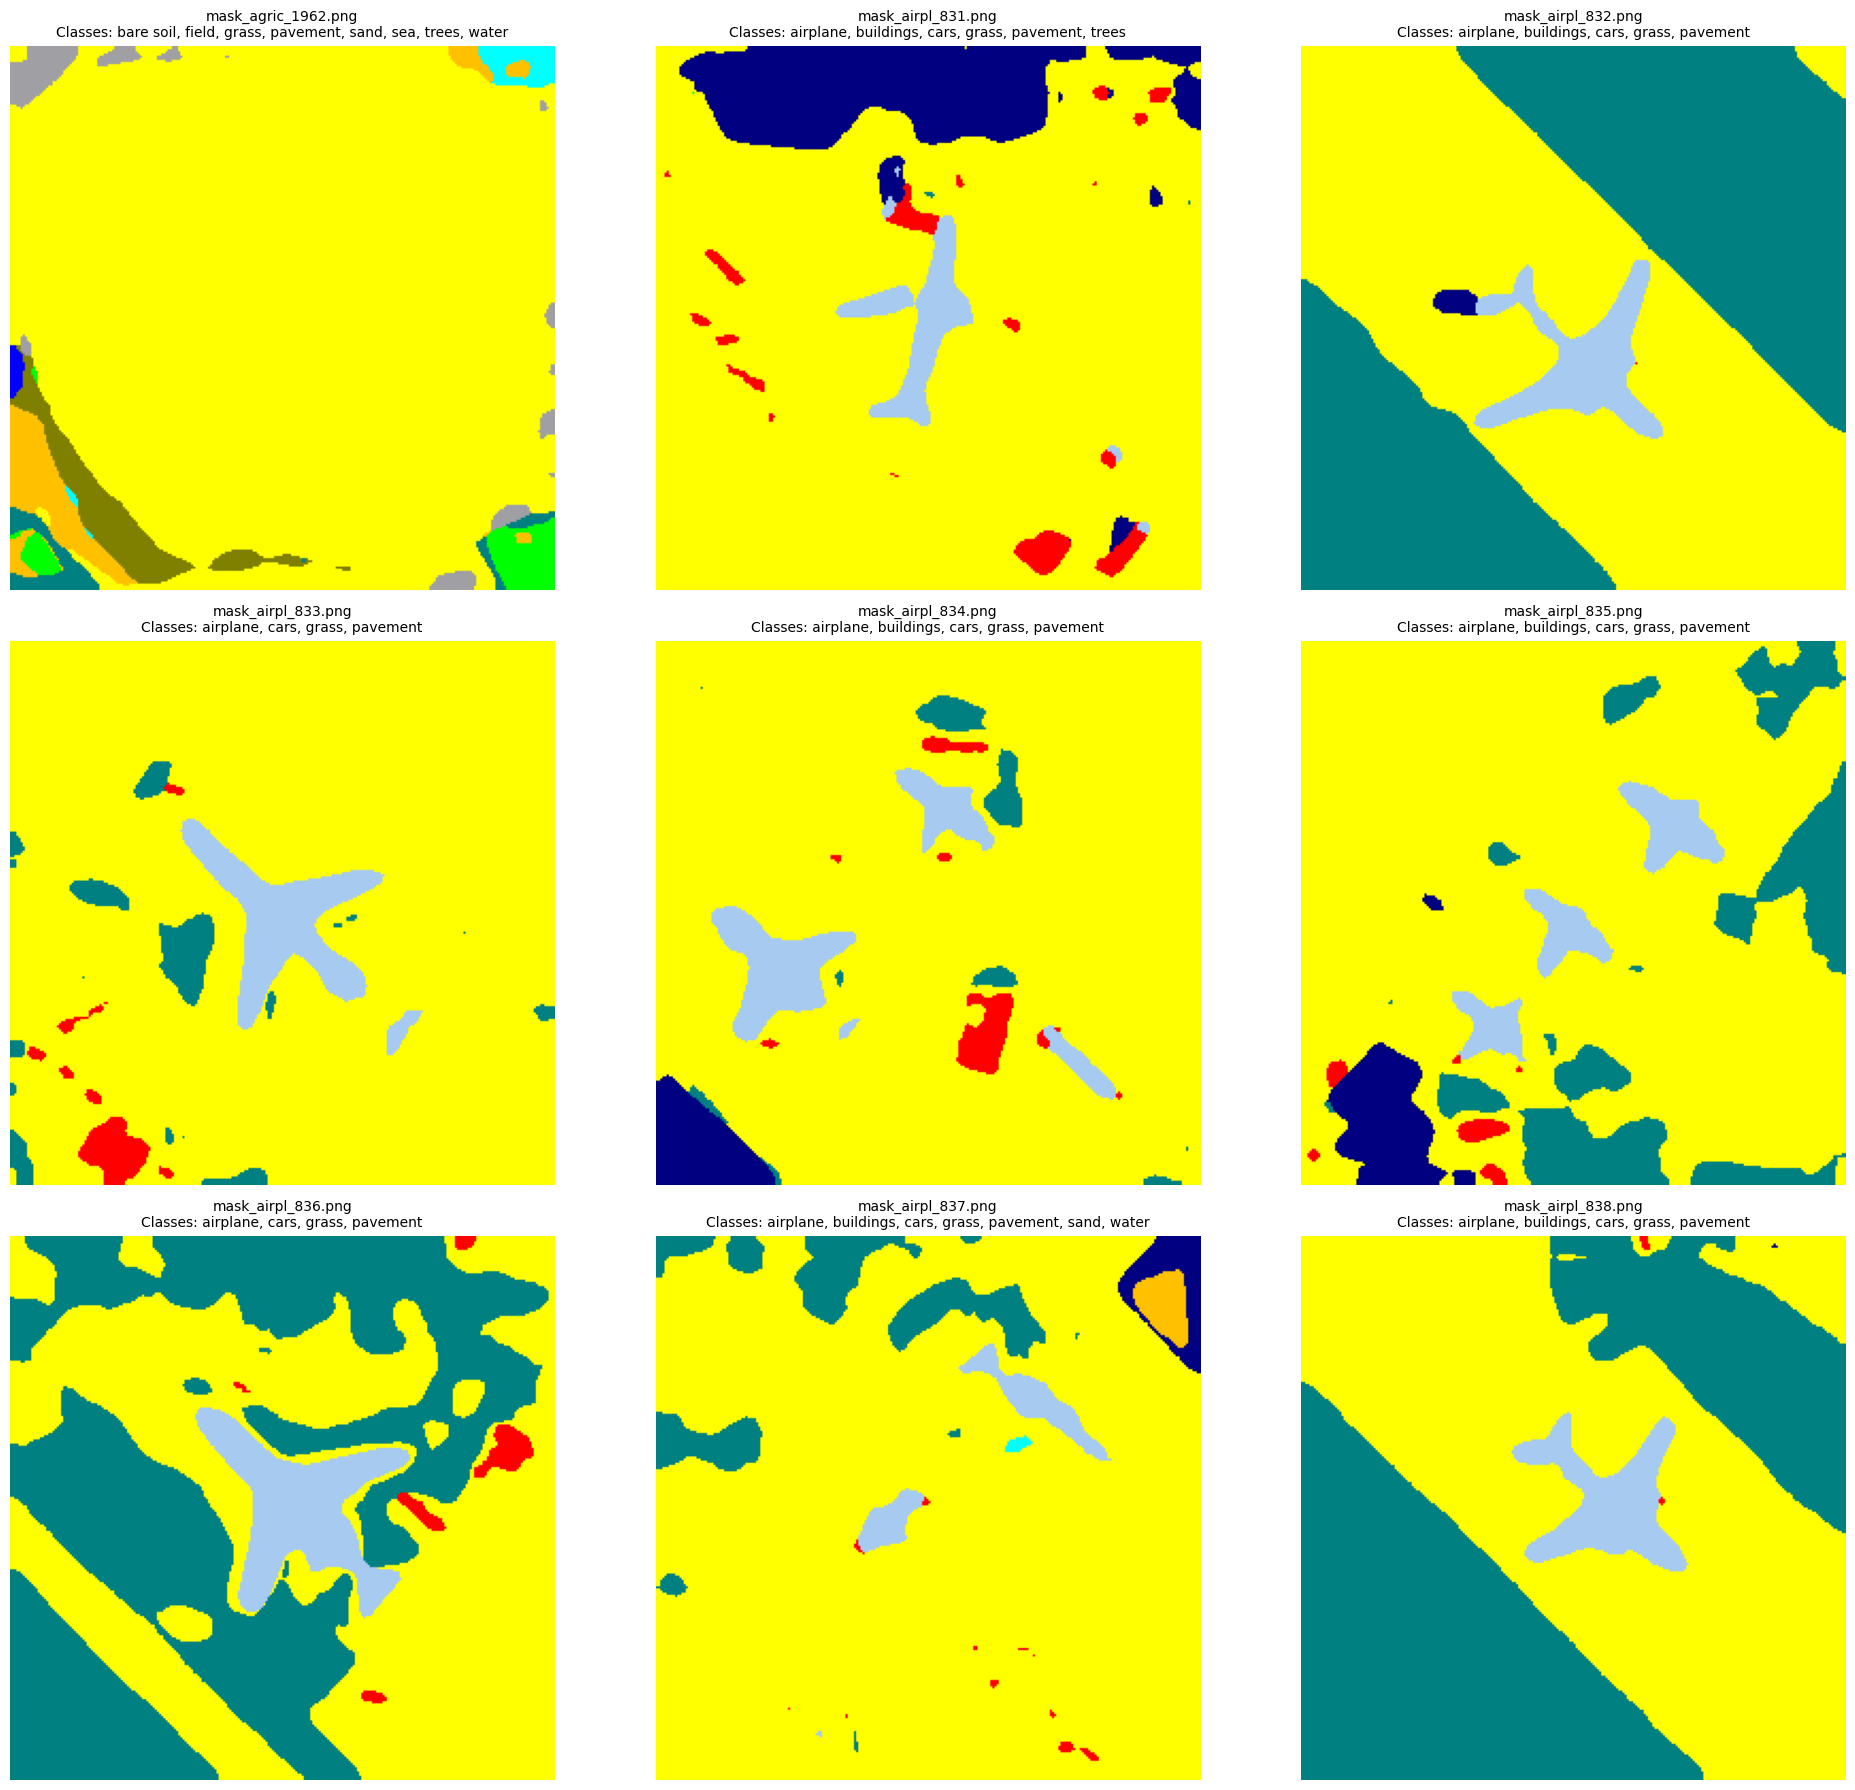

Multi-class semantic segmentation completed!


In [1]:
import torch
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from segment_anything import sam_model_registry
from torch.optim import Adam
import torch.nn as nn
from glob import glob

# ==================== CONFIGURATION ====================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train_image_dir = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/merged_dataset/images'
train_mask_dir = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/merged_dataset/1cmask'
test_image_dir = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/full_test_images'
output_dir = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/confident_test_finetune_sam_output'
sam_checkpoint ="/home/iiitdmk-param/Desktop/sam_vit_b.pth"
model_type = "vit_b"

# ==================== CLASS DEFINITIONS ====================
CLASS_INFO = {
    0: {"name": "background", "rgb": [0, 0, 0]},
    1: {"name": "airplane", "rgb": [166, 202, 240]},
    2: {"name": "bare soil", "rgb": [128, 128, 0]},
    3: {"name": "buildings", "rgb": [0, 0, 128]},
    4: {"name": "cars", "rgb": [255, 0, 0]},
    5: {"name": "chaparral", "rgb": [0, 128, 0]},
    6: {"name": "court", "rgb": [128, 0, 0]},
    7: {"name": "dock", "rgb": [255, 233, 233]},
    8: {"name": "field", "rgb": [160, 160, 164]},
    9: {"name": "grass", "rgb": [0, 128, 128]},
    10: {"name": "mobile home", "rgb": [90, 87, 255]},
    11: {"name": "pavement", "rgb": [255, 255, 0]},
    12: {"name": "sand", "rgb": [255, 192, 0]},
    13: {"name": "sea", "rgb": [0, 0, 255]},
    14: {"name": "ship", "rgb": [255, 0, 192]},
    15: {"name": "tanks", "rgb": [128, 0, 128]},
    16: {"name": "trees", "rgb": [0, 255, 0]},
    17: {"name": "water", "rgb": [0, 255, 255]}
}

NUM_CLASSES = len(CLASS_INFO)
print(f"Number of classes: {NUM_CLASSES}")

# ==================== DATA ANALYSIS ====================
def analyze_ground_truth_masks(mask_dir):
    """Check what class IDs are present in ground truth masks"""
    mask_files = [f for f in os.listdir(mask_dir) if f.endswith('.png')]
    
    print("=== ANALYZING GROUND TRUTH MASKS ===")
    all_class_ids = set()
    
    for mask_file in mask_files[:10]:
        mask_path = os.path.join(mask_dir, mask_file)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        
        if mask is not None:
            unique_ids = np.unique(mask)
            all_class_ids.update(unique_ids)
            print(f"{mask_file}: Unique class IDs: {unique_ids}")
    
    class_ids = sorted(all_class_ids)
    print(f"\nAll unique class IDs found: {class_ids}")
    print(f"Number of classes in data: {len(class_ids)}")
    
    # Check if any class IDs are outside our expected range
    unexpected_classes = [cid for cid in class_ids if cid not in CLASS_INFO]
    if unexpected_classes:
        print(f"⚠️  Warning: Unexpected class IDs found: {unexpected_classes}")
    
    return class_ids

# Analyze ground truth masks
class_ids = analyze_ground_truth_masks(train_mask_dir)

# ==================== MULTI-CLASS SAM WRAPPER ====================
class MultiClassSAMWrapper(nn.Module):
    def __init__(self, sam_model, num_classes):
        super().__init__()
        self.sam = sam_model
        self.num_classes = num_classes
        
        # Add custom multi-class head with more capacity
        self.multi_class_head = nn.Sequential(
            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.1),
            nn.Conv2d(256, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.1),
            nn.Conv2d(128, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, num_classes, 1)
        )
        
        # Freeze SAM parameters, only train custom head
        for param in self.sam.parameters():
            param.requires_grad = False
    
    def forward(self, x):
        # Get image embeddings from SAM
        with torch.no_grad():
            image_embeddings = self.sam.image_encoder(x)
        
        # Pass through multi-class head
        logits = self.multi_class_head(image_embeddings)
        return logits

# ==================== DATASET AND TRANSFORMS ====================
class SimpleTransform:
    def __call__(self, image, mask):
        # Resize to SAM input size
        image = cv2.resize(image, (1024, 1024))
        mask = cv2.resize(mask, (1024, 1024), interpolation=cv2.INTER_NEAREST)
        
        # Normalize image
        image = image.astype(np.float32) / 255.0
        image = (image - np.array([0.485, 0.456, 0.406])) / np.array([0.229, 0.224, 0.225])  # ImageNet normalization
        
        # Convert to tensor
        image = torch.from_numpy(image).permute(2, 0, 1).float()
        mask = torch.from_numpy(mask).long()  # Keep as class IDs
        
        return image, mask

class MultiClassSAMDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.image_files = sorted([f for f in os.listdir(image_dir) if f.endswith(('.png', '.jpg', '.jpeg'))])
        
    def __len__(self):
        return len(self.image_files)
    
    def __getitem__(self, idx):
        image_path = os.path.join(self.image_dir, self.image_files[idx])
        mask_name = self.image_files[idx].split('.')[0] + '.png'
        mask_path = os.path.join(self.mask_dir, mask_name)
        
        # Load image
        image = cv2.imread(image_path)
        if image is None:
            raise ValueError(f"Could not load image: {image_path}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Load mask - keep original class IDs
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            mask = np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)
        
        # Apply transformations
        if self.transform:
            image, mask = self.transform(image, mask)
        
        return {'image': image, 'mask': mask}

# ==================== TRAINING FUNCTION ====================
def train_multi_class_sam(model, train_loader, val_loader, num_epochs=100, lr=1e-3):
    model = model.to(device)
    
    # Use class-weighted loss to handle class imbalance
    class_weights = torch.ones(NUM_CLASSES).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    
    optimizer = Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5, verbose=True)
    
    best_val_loss = float('inf')
    
    for epoch in range(num_epochs):
        # Training
        model.train()
        train_loss = 0
        num_samples = 0
        
        for batch_idx, batch in enumerate(train_loader):
            images = batch['image'].to(device)
            masks = batch['mask'].to(device)
            
            optimizer.zero_grad()
            
            # Forward pass
            logits = model(images)
            
            # Resize logits to match mask size if needed
            if logits.shape[2:] != masks.shape[1:]:
                logits = torch.nn.functional.interpolate(
                    logits, size=masks.shape[1:], mode='bilinear', align_corners=False
                )
            
            loss = criterion(logits, masks)
            loss.backward()
            
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            
            train_loss += loss.item()
            num_samples += images.size(0)
            
            if batch_idx % 10 == 0:
                print(f'Epoch {epoch+1}, Batch {batch_idx}, Loss: {loss.item():.4f}')
        
        # Validation
        model.eval()
        val_loss = 0
        num_val_samples = 0
        
        with torch.no_grad():
            for batch in val_loader:
                images = batch['image'].to(device)
                masks = batch['mask'].to(device)
                
                logits = model(images)
                
                if logits.shape[2:] != masks.shape[1:]:
                    logits = torch.nn.functional.interpolate(
                        logits, size=masks.shape[1:], mode='bilinear', align_corners=False
                    )
                
                loss = criterion(logits, masks)
                val_loss += loss.item()
                num_val_samples += images.size(0)
        
        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        
        scheduler.step(avg_val_loss)
        
        print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, LR: {optimizer.param_groups[0]["lr"]:.2e}')
        
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': best_val_loss,
                'num_classes': NUM_CLASSES,
                'class_info': CLASS_INFO,
            }, 'confident_best_multi_class_sam.pth')
            print(f'✅ Saved new best model with val loss: {best_val_loss:.4f}')
    
    return model

# ==================== PREDICTION FUNCTION ====================
def predict_multi_class_masks(model, test_image_dir, output_dir, device='cuda'):
    os.makedirs(output_dir, exist_ok=True)
    model.eval()
    
    image_files = sorted([f for f in os.listdir(test_image_dir) if f.endswith(('.png', '.jpg', '.jpeg'))])
    
    for image_file in image_files:
        image_path = os.path.join(test_image_dir, image_file)
        
        # Load and preprocess image
        image = cv2.imread(image_path)
        if image is None:
            print(f"Could not load image: {image_file}")
            continue
            
        original_image = image.copy()
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        original_size = image_rgb.shape[:2]
        
        # Preprocess image
        input_image = cv2.resize(image_rgb, (1024, 1024))
        input_image = input_image.astype(np.float32) / 255.0
        input_image = (input_image - np.array([0.485, 0.456, 0.406])) / np.array([0.229, 0.224, 0.225])
        
        input_image_tensor = torch.from_numpy(input_image).permute(2, 0, 1).float().to(device)
        input_image_tensor = input_image_tensor.unsqueeze(0)
        
        with torch.no_grad():
            # Get predictions
            logits = model(input_image_tensor)
            
            # Resize to original size
            logits = torch.nn.functional.interpolate(
                logits, size=original_size, mode='bilinear', align_corners=False
            )
            
            # Get class predictions
            predictions = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()
        
        # Convert to uint8 and save
        predictions_uint8 = predictions.astype(np.uint8)
        output_path = os.path.join(output_dir, f'mask_{image_file}')
        cv2.imwrite(output_path, predictions_uint8)
        
        # Analyze the prediction
        unique_values = np.unique(predictions_uint8)
        class_names = [CLASS_INFO.get(val, {"name": f"unknown_{val}"})["name"] for val in unique_values]
        print(f'Saved mask for {image_file} - Classes: {list(zip(unique_values, class_names))}')
    
    print("All predictions completed!")

# ==================== VISUALIZATION FUNCTIONS ====================
def visualize_predictions(predictions_folder, num_samples=9):
    """Visualize prediction masks with proper class colors"""
    image_files = sorted([f for f in os.listdir(predictions_folder) if f.endswith(('.png', '.jpg', '.jpeg'))])
    
    num_images = min(len(image_files), num_samples)
    cols = 3
    rows = (num_images + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(20, 6*rows))
    axes = axes.flatten() if rows > 1 else [axes]
    
    for i, image_file in enumerate(image_files[:num_images]):
        image_path = os.path.join(predictions_folder, image_file)
        mask = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        
        if mask is None:
            continue
        
        # Create colored mask using class RGB values
        colored_mask = np.zeros((mask.shape[0], mask.shape[1], 3), dtype=np.uint8)
        for class_id, info in CLASS_INFO.items():
            colored_mask[mask == class_id] = info["rgb"]
        
        axes[i].imshow(colored_mask)
        
        # Get unique classes in this mask
        unique_classes = np.unique(mask)
        class_names = [CLASS_INFO.get(cid, {"name": f"unknown_{cid}"})["name"] for cid in unique_classes]
        
        axes[i].set_title(f'{image_file}\nClasses: {", ".join(class_names)}', fontsize=10)
        axes[i].axis('off')
    
    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    
    plt.tight_layout()
    plt.show()

def analyze_predictions(predictions_folder):
    """Analyze prediction masks with class distribution"""
    image_files = sorted([f for f in os.listdir(predictions_folder) if f.endswith('.png')])
    
    print("=== PREDICTION ANALYSIS ===")
    all_class_ids = set()
    class_distribution = {class_id: 0 for class_id in CLASS_INFO.keys()}
    
    for image_file in image_files:
        image_path = os.path.join(predictions_folder, image_file)
        mask = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        
        if mask is not None:
            unique_ids = np.unique(mask)
            all_class_ids.update(unique_ids)
            
            # Count pixels for each class
            for class_id in unique_ids:
                if class_id in class_distribution:
                    class_distribution[class_id] += np.sum(mask == class_id)
            
            class_names = [CLASS_INFO.get(cid, {"name": f"unknown_{cid}"})["name"] for cid in unique_ids]
            print(f"{image_file}: Classes {unique_ids} ({class_names})")
    
    print(f"\nAll classes in predictions: {sorted(all_class_ids)}")
    
    # Print class distribution
    print("\n=== CLASS DISTRIBUTION ===")
    total_pixels = sum(class_distribution.values())
    for class_id, count in class_distribution.items():
        if count > 0:
            percentage = (count / total_pixels) * 100
            class_name = CLASS_INFO[class_id]["name"]
            print(f"{class_name} (ID {class_id}): {count} pixels ({percentage:.2f}%)")

# ==================== MAIN EXECUTION ====================
def main():
    print("Loading SAM model...")
    sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
    
    # Create multi-class model
    model = MultiClassSAMWrapper(sam, NUM_CLASSES)
    print(f"Model created with {NUM_CLASSES} classes")
    
    # Create datasets
    transform = SimpleTransform()
    dataset = MultiClassSAMDataset(train_image_dir, train_mask_dir, transform)
    
    # Split dataset
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])
    
    train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False, num_workers=2)
    
    print(f"Training on {len(train_dataset)} samples, validating on {len(val_dataset)} samples")
    
    # Train the model
    print("Starting training...")
    trained_model = train_multi_class_sam(model, train_loader, val_loader, num_epochs=100, lr=1e-3)
    
    # Predict on test images
    print("Starting prediction...")
    predict_multi_class_masks(trained_model, test_image_dir, output_dir, device)
    
    # Analyze and visualize predictions
    print("Analyzing predictions...")
    analyze_predictions(output_dir)
    visualize_predictions(output_dir)
    
    print("Multi-class semantic segmentation completed!")

if __name__ == "__main__":
    main()

In [2]:
import numpy as np
import os
from PIL import Image

# Define the class information
CLASS_INFO = {
    0: {"name": "background", "rgb": [0, 0, 0]},
    1: {"name": "airplane", "rgb": [166, 202, 240]},
    2: {"name": "bare soil", "rgb": [128, 128, 0]},
    3: {"name": "buildings", "rgb": [0, 0, 128]},
    4: {"name": "cars", "rgb": [255, 0, 0]},
    5: {"name": "chaparral", "rgb": [0, 128, 0]},
    6: {"name": "court", "rgb": [128, 0, 0]},
    7: {"name": "dock", "rgb": [255, 233, 233]},
    8: {"name": "field", "rgb": [160, 160, 164]},
    9: {"name": "grass", "rgb": [0, 128, 128]},
    10: {"name": "mobile home", "rgb": [90, 87, 255]},
    11: {"name": "pavement", "rgb": [255, 255, 0]},
    12: {"name": "sand", "rgb": [255, 192, 0]},
    13: {"name": "sea", "rgb": [0, 0, 255]},
    14: {"name": "ship", "rgb": [255, 0, 192]},
    15: {"name": "tanks", "rgb": [128, 0, 128]},
    16: {"name": "trees", "rgb": [0, 255, 0]},
    17: {"name": "water", "rgb": [0, 255, 255]}
}

def one_channel_to_rgb(one_channel_mask):
    """
    Convert 1-channel mask back to RGB for visualization.
    
    Args:
        one_channel_mask: numpy array of shape (H, W) with class indices
        
    Returns:
        rgb_mask: numpy array of shape (H, W, 3) with RGB values
    """
    h, w = one_channel_mask.shape
    rgb_mask = np.zeros((h, w, 3), dtype=np.uint8)
    
    for class_idx, class_info in CLASS_INFO.items():
        mask = one_channel_mask == class_idx
        rgb_mask[mask] = class_info["rgb"]
    
    return rgb_mask

def convert_1channel_to_rgb(input_folder, output_folder):
    """
    Convert all 1-channel masks in input_folder to RGB masks and save to output_folder.
    
    Args:
        input_folder: path to folder containing 1-channel masks
        output_folder: path to folder where RGB masks will be saved
    """
    # Create output folder if it doesn't exist
    os.makedirs(output_folder, exist_ok=True)
    
    # Get all image files in input folder
    supported_formats = ('.png', '.jpg', '.jpeg', '.bmp', '.tiff')
    image_files = [f for f in os.listdir(input_folder) 
                  if f.lower().endswith(supported_formats)]
    
    print(f"Found {len(image_files)} masks to process in {input_folder}")
    
    # Process each image
    for i, filename in enumerate(image_files):
        # Load 1-channel mask
        input_path = os.path.join(input_folder, filename)
        one_channel_mask = np.array(Image.open(input_path))
        
        # Convert back to RGB
        rgb_mask = one_channel_to_rgb(one_channel_mask)
        
        # Save as PNG
        name, ext = os.path.splitext(filename)
        output_path = os.path.join(output_folder, f"{name}.png")
        
        # Save as PNG
        Image.fromarray(rgb_mask).save(output_path)
        
        if (i + 1) % 10 == 0 or (i + 1) == len(image_files):
            print(f"Processed {i+1}/{len(image_files)}: {filename} -> {output_path}")
    
    print(f"All masks converted and saved to {output_folder}")

# Set your paths here
input_folder = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/confident_test_finetune_sam_output'
output_folder = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/confident_test_finetune_sam_output_rgb'

# Check if input folder exists
if not os.path.exists(input_folder):
    print(f"Error: Input folder '{input_folder}' does not exist!")
else:
    # Convert all masks
    convert_1channel_to_rgb(input_folder, output_folder)
    print("Conversion completed successfully!")

Found 1319 masks to process in /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/confident_test_finetune_sam_output
Processed 10/1319: mask_build_1652.png -> /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/confident_test_finetune_sam_output_rgb/mask_build_1652.png
Processed 20/1319: mask_build_1698.png -> /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/confident_test_finetune_sam_output_rgb/mask_build_1698.png
Processed 30/1319: mask_harbo_465.png -> /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/confident_test_finetune_sam_output_rgb/mask_harbo_465.png
Processed 40/1319: mask_beach_1175.png -> /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/confident_test_finetune_sam_output_rgb/mask_beach_1175.png
Processed 50/1319: mask_dense_1464.png -> /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/confident_test_finetune_sam_output_rgb/mask_dense_1464.png
Processed 60/1319: mask_parki_282.png -> /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/confident_test_finetune_sam_outpu

In [4]:
import os
import numpy as np
from PIL import Image

# Define the class information
CLASS_INFO = {
    0: {"name": "background", "rgb": [0, 0, 0]},
    1: {"name": "airplane", "rgb": [166, 202, 240]},
    2: {"name": "bare soil", "rgb": [128, 128, 0]},
    3: {"name": "buildings", "rgb": [0, 0, 128]},
    4: {"name": "cars", "rgb": [255, 0, 0]},
    5: {"name": "chaparral", "rgb": [0, 128, 0]},
    6: {"name": "court", "rgb": [128, 0, 0]},
    7: {"name": "dock", "rgb": [255, 233, 233]},
    8: {"name": "field", "rgb": [160, 160, 164]},
    9: {"name": "grass", "rgb": [0, 128, 128]},
    10: {"name": "mobile home", "rgb": [90, 87, 255]},
    11: {"name": "pavement", "rgb": [255, 255, 0]},
    12: {"name": "sand", "rgb": [255, 192, 0]},
    13: {"name": "sea", "rgb": [0, 0, 255]},
    14: {"name": "ship", "rgb": [255, 0, 192]},
    15: {"name": "tanks", "rgb": [128, 0, 128]},
    16: {"name": "trees", "rgb": [0, 255, 0]},
    17: {"name": "water", "rgb": [0, 255, 255]}
}

def calculate_detailed_miou(gt_folder, pred_folder, num_classes=18, ignore_index=None):
    """
    Calculate detailed mIoU with per-class results
    """
    
    gt_files = sorted([f for f in os.listdir(gt_folder) if f.endswith(('.png', '.jpg', '.jpeg', '.tiff'))])
    pred_files = sorted([f for f in os.listdir(pred_folder) if f.endswith(('.png', '.jpg', '.jpeg', '.tiff'))])
    
    assert len(gt_files) == len(pred_files), f"Number of files don't match: GT={len(gt_files)}, Pred={len(pred_files)}"
    
    # Initialize intersection and union arrays
    total_intersection = np.zeros(num_classes)
    total_union = np.zeros(num_classes)
    class_pixels = np.zeros(num_classes)  # For pixel accuracy
    
    print(f"Processing {len(gt_files)} images...")
    
    for i, (gt_file, pred_file) in enumerate(zip(gt_files, pred_files)):
        gt_path = os.path.join(gt_folder, gt_file)
        pred_path = os.path.join(pred_folder, pred_file)
        
        # Load 1-channel masks
        gt_mask = np.array(Image.open(gt_path))
        pred_mask = np.array(Image.open(pred_path))
        
        # Ensure masks have the same shape
        assert gt_mask.shape == pred_mask.shape, f"Shape mismatch: GT{gt_mask.shape} vs Pred{pred_mask.shape}"
        
        # Calculate IoU for each class
        for class_id in range(num_classes):
            if ignore_index is not None and class_id == ignore_index:
                continue
                
            gt_class = (gt_mask == class_id)
            pred_class = (pred_mask == class_id)
            
            intersection = np.logical_and(gt_class, pred_class).sum()
            union = np.logical_or(gt_class, pred_class).sum()
            
            total_intersection[class_id] += intersection
            total_union[class_id] += union
            class_pixels[class_id] += gt_class.sum()
        
        if (i + 1) % 100 == 0:
            print(f"Processed {i + 1}/{len(gt_files)} images")
    
    # Calculate IoU for each class
    iou_per_class = np.zeros(num_classes)
    for class_id in range(num_classes):
        if total_union[class_id] > 0:
            iou_per_class[class_id] = total_intersection[class_id] / total_union[class_id]
        else:
            iou_per_class[class_id] = np.nan
    
    # Calculate mIoU (mean over classes, ignoring NaN)
    valid_classes = ~np.isnan(iou_per_class)
    miou = np.mean(iou_per_class[valid_classes])
    
    # Calculate pixel accuracy
    pixel_accuracy = total_intersection.sum() / class_pixels.sum() if class_pixels.sum() > 0 else 0
    
    return miou, iou_per_class, pixel_accuracy

# Usage with detailed results
gt_folder = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/full_test_1cmasks'
pred_folder = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/confident_test_finetune_sam_output'
num_classes = 18

miou, iou_per_class, pixel_acc = calculate_detailed_miou(gt_folder, pred_folder, num_classes)

print("\n" + "="*50)
print("SEMANTIC SEGMENTATION RESULTS")
print("="*50)
print(f"mIoU: {miou:.4f}")
print(f"Pixel Accuracy: {pixel_acc:.4f}")
print("\nPer-class IoU:")
for class_id in range(num_classes):
    class_name = CLASS_INFO[class_id]["name"]
    iou = iou_per_class[class_id]
    if not np.isnan(iou):
        print(f"  {class_name:15}: {iou:.4f}")
    else:
        print(f"  {class_name:15}: No pixels")

Processing 1319 images...
Processed 100/1319 images
Processed 200/1319 images
Processed 300/1319 images
Processed 400/1319 images
Processed 500/1319 images
Processed 600/1319 images
Processed 700/1319 images
Processed 800/1319 images
Processed 900/1319 images
Processed 1000/1319 images
Processed 1100/1319 images
Processed 1200/1319 images
Processed 1300/1319 images

SEMANTIC SEGMENTATION RESULTS
mIoU: 0.3361
Pixel Accuracy: 0.6122

Per-class IoU:
  background     : No pixels
  airplane       : 0.4740
  bare soil      : 0.1982
  buildings      : 0.4468
  cars           : 0.5111
  chaparral      : 0.0506
  court          : 0.5642
  dock           : 0.0867
  field          : 0.0068
  grass          : 0.4726
  mobile home    : 0.1605
  pavement       : 0.5835
  sand           : 0.2756
  sea            : 0.6380
  ship           : 0.0482
  tanks          : 0.3761
  trees          : 0.4027
  water          : 0.4176


In [ ]:
confident_best_multi_class_sam

Number of classes: 18
🚀 Starting inference with point refinement...
🔄 Loading SAM base model...
🔄 Creating wrapper model...
🔄 Loading pre-trained weights from confident_best_multi_class_sam.pth...


/tmp/ipykernel_1321556/2448560353.py:182: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(pretrained_path, map_location=device)


✅ Loaded model from epoch 54 with val loss: 0.9500
🔍 Loading point annotations...
📸 Found 1319 test images

🎉 All refined predictions completed!

=== PREDICTION ANALYSIS ===
All classes in predictions: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]

=== CLASS DISTRIBUTION ===
airplane (ID 1): 351857 pixels (0.41%)
bare soil (ID 2): 6765291 pixels (7.83%)
buildings (ID 3): 9758264 pixels (11.29%)
cars (ID 4): 2031752 pixels (2.35%)
chaparral (ID 5): 3600319 pixels (4.17%)
court (ID 6): 927364 pixels (1.07%)
dock (ID 7): 853232 pixels (0.99%)
field (ID 8): 147859 pixels (0.17%)
grass (ID 9): 12666065 pixels (14.65%)
mobile home (ID 10): 1248208 pixels (1.44%)
pavement (ID 11): 26685800 pixels (30.87%)
sand (ID 12): 3576111 pixels (4.14%)
sea (ID 13): 2901501 pixels (3.36%)
ship (ID 14): 63583 pixels (0.07%)
tanks (ID 15): 692016 pixels (0.80%)
trees (ID 16): 9402983 pixels (10.88%)
water (ID 17): 4769779 pixels (5.52%)


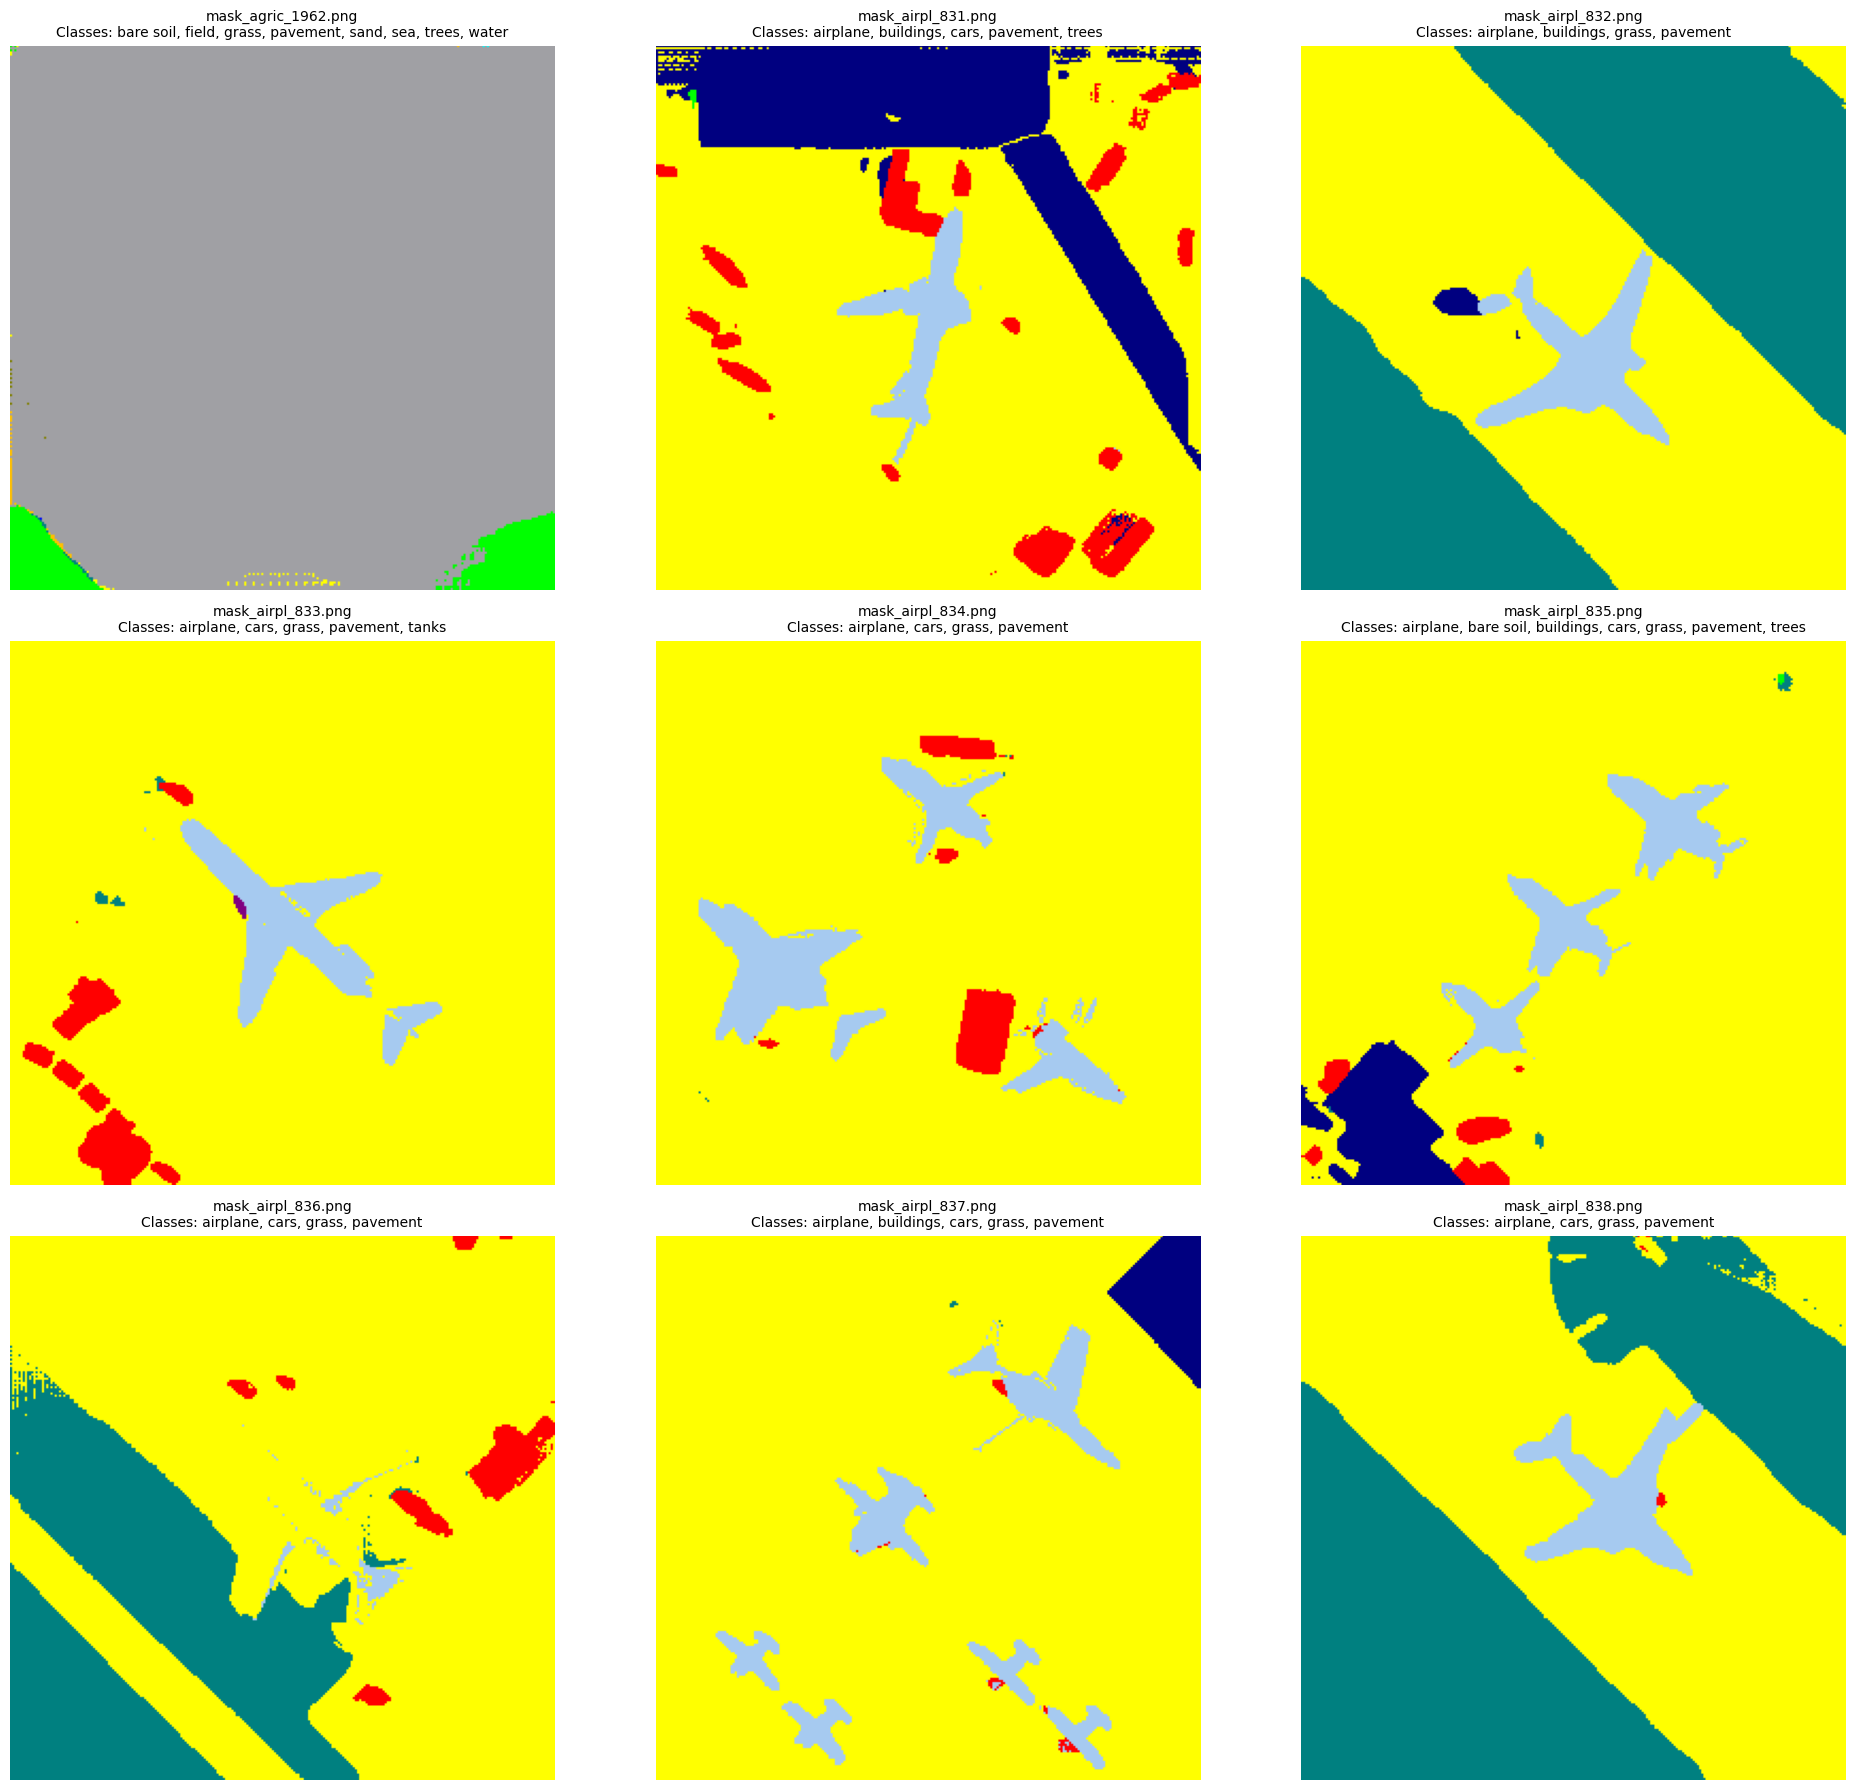


🎯 Inference with point refinement completed successfully!


In [5]:
import torch
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from segment_anything import sam_model_registry
from torch.optim import Adam
import torch.nn as nn
from glob import glob

# ==================== CONFIGURATION ====================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
test_image_dir = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/full_test_images'
point_annotation_dir = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/full_test_point_masks'
output_dir = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/full_test_confident_finetune_sam_output_pointprompts'
sam_checkpoint = "/home/iiitdmk-param/Desktop/sam_vit_b.pth"
model_type = "vit_b"
pretrained_model_path = 'confident_best_multi_class_sam.pth'  # Your pre-trained model

# ==================== CLASS DEFINITIONS ====================
CLASS_INFO = {
    0: {"name": "background", "rgb": [0, 0, 0]},
    1: {"name": "airplane", "rgb": [166, 202, 240]},
    2: {"name": "bare soil", "rgb": [128, 128, 0]},
    3: {"name": "buildings", "rgb": [0, 0, 128]},
    4: {"name": "cars", "rgb": [255, 0, 0]},
    5: {"name": "chaparral", "rgb": [0, 128, 0]},
    6: {"name": "court", "rgb": [128, 0, 0]},
    7: {"name": "dock", "rgb": [255, 233, 233]},
    8: {"name": "field", "rgb": [160, 160, 164]},
    9: {"name": "grass", "rgb": [0, 128, 128]},
    10: {"name": "mobile home", "rgb": [90, 87, 255]},
    11: {"name": "pavement", "rgb": [255, 255, 0]},
    12: {"name": "sand", "rgb": [255, 192, 0]},
    13: {"name": "sea", "rgb": [0, 0, 255]},
    14: {"name": "ship", "rgb": [255, 0, 192]},
    15: {"name": "tanks", "rgb": [128, 0, 128]},
    16: {"name": "trees", "rgb": [0, 255, 0]},
    17: {"name": "water", "rgb": [0, 255, 255]}
}

NUM_CLASSES = len(CLASS_INFO)
print(f"Number of classes: {NUM_CLASSES}")

# ==================== POINT ANNOTATION LOADING ====================
def load_point_annotations(point_annotation_dir, image_files):
    """Load RGB point annotations and convert to class coordinates, ignoring (100,100,100) pixels"""
    point_prompts = {}
    ignore_color = np.array([100, 100, 100])  # Color to ignore
    
    print("🔍 Loading point annotations...")
    
    for image_file in image_files:
        base_name = image_file.split('.')[0]
        point_path = os.path.join(point_annotation_dir, f"{base_name}.png")
        
        if os.path.exists(point_path):
            point_mask = cv2.imread(point_path)
            if point_mask is None:
                #print(f"  ❌ Could not load point mask: {base_name}.png")
                continue
                
            point_mask = cv2.cvtColor(point_mask, cv2.COLOR_BGR2RGB)
            original_size = point_mask.shape[:2]
            
            # Create ignore mask (pixels that are NOT ignore color)
            non_ignore_mask = ~np.all(point_mask == ignore_color, axis=-1)
            
            # Extract point prompts for each class
            class_points = {}
            total_points = 0
            
            for class_id, info in CLASS_INFO.items():
                if class_id == 0:  # Skip background
                    continue
                    
                target_color = np.array(info["rgb"])
                # Find pixels that match this class color AND are not ignore color
                mask = np.all(point_mask == target_color, axis=-1) & non_ignore_mask
                
                if np.any(mask):
                    # Get coordinates of points
                    y_coords, x_coords = np.where(mask)
                    points = list(zip(x_coords, y_coords))
                    class_points[class_id] = points
                    total_points += len(points)
                    
                    #print(f"    {info['name']} (ID {class_id}): {len(points)} points")
            
            point_prompts[base_name] = class_points
            
            #if total_points > 0:
                #print(f"  ✅ {base_name}: {total_points} total points across {len(class_points)} classes")
            #else:
                #print(f"  ⚠️  {base_name}: No valid points found (only background/ignore colors)")
        #else:
            #print(f"  ❌ Point annotations not found for: {base_name}")
    
    # Summary
    images_with_points = sum(1 for points in point_prompts.values() if points)
    total_points_all = sum(sum(len(points) for points in classes.values()) for classes in point_prompts.values())
    
    #print(f"\n📊 Summary: {images_with_points}/{len(image_files)} images have point annotations")
    #print(f"📊 Total points across all images: {total_points_all}")
    
    return point_prompts

# ==================== MULTI-CLASS SAM WRAPPER ====================
class MultiClassSAMWrapper(nn.Module):
    def __init__(self, sam_model, num_classes):
        super().__init__()
        self.sam = sam_model
        self.num_classes = num_classes
        
        # Add custom multi-class head with more capacity (EXACTLY LIKE YOUR TRAINING)
        self.multi_class_head = nn.Sequential(
            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.1),
            nn.Conv2d(256, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.1),
            nn.Conv2d(128, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, num_classes, 1)
        )
        
        # Freeze SAM parameters (EXACTLY LIKE YOUR TRAINING)
        for param in self.sam.parameters():
            param.requires_grad = False
    
    def forward(self, x):
        # Get image embeddings from SAM
        with torch.no_grad():
            image_embeddings = self.sam.image_encoder(x)
        
        # Pass through multi-class head
        logits = self.multi_class_head(image_embeddings)
        return logits
    
    def get_sam_embedding(self, x):
        """Get SAM image embeddings for point refinement"""
        with torch.no_grad():
            return self.sam.image_encoder(x)
    
    def prompt_guided_prediction(self, image_embedding, point_coords, point_labels):
        """Use SAM's prompt encoder and mask decoder for point refinement"""
        sparse_embeddings, dense_embeddings = self.sam.prompt_encoder(
            points=(point_coords, point_labels),
            boxes=None,
            masks=None,
        )
        
        low_res_masks, iou_predictions = self.sam.mask_decoder(
            image_embeddings=image_embedding,
            image_pe=self.sam.prompt_encoder.get_dense_pe(),
            sparse_prompt_embeddings=sparse_embeddings,
            dense_prompt_embeddings=dense_embeddings,
            multimask_output=False,
        )
        
        return low_res_masks

# ==================== LOAD PRE-TRAINED MODEL ====================
def load_pretrained_model(pretrained_path, sam_checkpoint, model_type, num_classes):
    """Load your pre-trained fine-tuned SAM model"""
    print("🔄 Loading SAM base model...")
    sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
    
    print("🔄 Creating wrapper model...")
    model = MultiClassSAMWrapper(sam, num_classes)
    
    print(f"🔄 Loading pre-trained weights from {pretrained_path}...")
    
    if not os.path.exists(pretrained_path):
        raise FileNotFoundError(f"❌ Pre-trained model not found at: {pretrained_path}")
    
    checkpoint = torch.load(pretrained_path, map_location=device)
    
    # Load model state
    model.load_state_dict(checkpoint['model_state_dict'])
    
    # Get training info
    epoch = checkpoint.get('epoch', 'Unknown')
    loss = checkpoint.get('loss', 'Unknown')
    print(f"✅ Loaded model from epoch {epoch} with val loss: {loss:.4f}")
    
    return model

# ==================== PREDICTION WITH POINT REFINEMENT ====================
def get_initial_prediction(model, image_rgb, original_size, device):
    """Get initial dense 1-channel prediction using your fine-tuned model"""
    # Preprocess image (EXACTLY LIKE YOUR TRAINING)
    input_image = cv2.resize(image_rgb, (1024, 1024))
    input_image = input_image.astype(np.float32) / 255.0
    input_image = (input_image - np.array([0.485, 0.456, 0.406])) / np.array([0.229, 0.224, 0.225])
    
    input_image_tensor = torch.from_numpy(input_image).permute(2, 0, 1).float().to(device)
    input_image_tensor = input_image_tensor.unsqueeze(0)
    
    with torch.no_grad():
        logits = model(input_image_tensor)
        logits = torch.nn.functional.interpolate(
            logits, size=original_size, mode='bilinear', align_corners=False
        )
        predictions = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()
    
    return predictions

def refine_with_points(model, image_rgb, initial_pred, class_points, original_size, device):
    """Refine initial 1-channel prediction using point prompts with fine-tuned SAM"""
    refined_pred = initial_pred.copy()
    
    if not class_points:
        return refined_pred
    
    # Preprocess image for SAM
    input_image = cv2.resize(image_rgb, (1024, 1024))
    input_image = input_image.astype(np.float32) / 255.0
    input_image = (input_image - np.array([0.485, 0.456, 0.406])) / np.array([0.229, 0.224, 0.225])
    input_image_tensor = torch.from_numpy(input_image).permute(2, 0, 1).float().to(device)
    
    # Get image embedding from your fine-tuned SAM
    with torch.no_grad():
        image_embedding = model.get_sam_embedding(input_image_tensor.unsqueeze(0))
    
    # Process each class with point prompts
    total_refined_pixels = 0
    
    for class_id, points in class_points.items():
        if len(points) == 0:
            continue
            
        #print(f"    🎯 Refining {CLASS_INFO[class_id]['name']} with {len(points)} points...")
        class_refined_pixels = 0
        
        for point_idx, point in enumerate(points):
            x, y = point
            
            # Scale points to 1024x1024
            x_scale = 1024 / original_size[1]
            y_scale = 1024 / original_size[0]
            x_sam = int(x * x_scale)
            y_sam = int(y * y_scale)
            
            # Ensure coordinates are within bounds
            x_sam = max(0, min(x_sam, 1023))
            y_sam = max(0, min(y_sam, 1023))
            
            # Create point prompt
            point_coords = torch.tensor([[[x_sam, y_sam]]], device=device).float()
            point_labels = torch.tensor([[1]], device=device).long()  # 1 = foreground
            
            # Get mask prediction from your fine-tuned SAM
            with torch.no_grad():
                low_res_masks = model.prompt_guided_prediction(
                    image_embedding, point_coords, point_labels
                )
                
                # Upscale mask to original size
                mask = torch.nn.functional.interpolate(
                    low_res_masks,
                    size=original_size,
                    mode="bilinear",
                    align_corners=False,
                )
                mask = mask.squeeze().cpu().numpy() > 0.0
            
            # Count how many pixels we're refining
            pixels_refined = np.sum(mask)
            class_refined_pixels += pixels_refined
            
            # OVERWRITE the entire region with the correct class ID
            refined_pred[mask] = class_id
        
        total_refined_pixels += class_refined_pixels
        #print(f"      ✅ {CLASS_INFO[class_id]['name']}: {class_refined_pixels} pixels refined")
    
    #print(f"    📊 Total refinement: {total_refined_pixels} pixels updated")
    return refined_pred

def predict_with_point_refinement(model, point_prompts, test_image_dir, output_dir, device='cuda'):
    """Predict using fine-tuned SAM with point prompt refinement"""
    os.makedirs(output_dir, exist_ok=True)
    model.eval()
    
    image_files = sorted([f for f in os.listdir(test_image_dir) if f.endswith(('.png', '.jpg', '.jpeg'))])
    
    print(f"📸 Found {len(image_files)} test images")
    
    for image_idx, image_file in enumerate(image_files, 1):
        image_path = os.path.join(test_image_dir, image_file)
        base_name = image_file.split('.')[0]
        
        # Load image
        image = cv2.imread(image_path)
        if image is None:
            print(f"❌ Could not load image: {image_file}")
            continue
            
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        original_size = image_rgb.shape[:2]
        
        #print(f"\n[{image_idx}/{len(image_files)}] 🔄 Processing {image_file} ({original_size[1]}x{original_size[0]})...")
        
        # Get initial 1-channel prediction from your fine-tuned model
        initial_prediction = get_initial_prediction(model, image_rgb, original_size, device)
        
        # Analyze initial prediction
        initial_classes = np.unique(initial_prediction)
        initial_class_names = [CLASS_INFO.get(cid, {"name": f"unknown_{cid}"})["name"] for cid in initial_classes]
        #print(f"  📊 Initial prediction classes: {list(zip(initial_classes, initial_class_names))}")
        
        # Refine with point prompts if available
        if base_name in point_prompts and point_prompts[base_name]:
            #print(f"  🔧 Refining with point annotations...")
            refined_prediction = refine_with_points(
                model, image_rgb, initial_prediction, point_prompts[base_name], original_size, device
            )
            refinement_type = "REFINED"
        else:
            refined_prediction = initial_prediction
            #print(f"  ⚠️  No point annotations found, using initial prediction")
            refinement_type = "INITIAL"
        
        # Save refined 1-channel prediction
        predictions_uint8 = refined_prediction.astype(np.uint8)
        output_path = os.path.join(output_dir, f'mask_{image_file}')
        cv2.imwrite(output_path, predictions_uint8)
        
        # Analyze final prediction
        final_classes = np.unique(refined_prediction)
        final_class_names = [CLASS_INFO.get(cid, {"name": f"unknown_{cid}"})["name"] for cid in final_classes]
        #print(f"  ✅ Saved {refinement_type} mask - Classes: {list(zip(final_classes, final_class_names))}")
    
    print("\n🎉 All refined predictions completed!")

# ==================== VISUALIZATION FUNCTIONS ====================
def visualize_predictions(predictions_folder, num_samples=9):
    """Visualize prediction masks with proper class colors"""
    image_files = sorted([f for f in os.listdir(predictions_folder) if f.endswith(('.png', '.jpg', '.jpeg'))])
    
    if not image_files:
        print("❌ No prediction files found for visualization")
        return
    
    num_images = min(len(image_files), num_samples)
    cols = 3
    rows = (num_images + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(20, 6*rows))
    if rows > 1:
        axes = axes.flatten()
    else:
        axes = [axes] if cols == 1 else axes
    
    for i, image_file in enumerate(image_files[:num_images]):
        image_path = os.path.join(predictions_folder, image_file)
        mask = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        
        if mask is None:
            continue
        
        # Create colored mask using class RGB values
        colored_mask = np.zeros((mask.shape[0], mask.shape[1], 3), dtype=np.uint8)
        for class_id, info in CLASS_INFO.items():
            colored_mask[mask == class_id] = info["rgb"]
        
        axes[i].imshow(colored_mask)
        
        # Get unique classes in this mask
        unique_classes = np.unique(mask)
        class_names = [CLASS_INFO.get(cid, {"name": f"unknown_{cid}"})["name"] for cid in unique_classes]
        
        axes[i].set_title(f'{image_file}\nClasses: {", ".join(class_names)}', fontsize=10)
        axes[i].axis('off')
    
    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    
    plt.tight_layout()
    plt.show()

def analyze_predictions(predictions_folder):
    """Analyze prediction masks with class distribution"""
    image_files = sorted([f for f in os.listdir(predictions_folder) if f.endswith('.png')])
    
    if not image_files:
        print("❌ No prediction files found for analysis")
        return
    
    print("\n=== PREDICTION ANALYSIS ===")
    all_class_ids = set()
    class_distribution = {class_id: 0 for class_id in CLASS_INFO.keys()}
    
    for image_file in image_files:
        image_path = os.path.join(predictions_folder, image_file)
        mask = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        
        if mask is not None:
            unique_ids = np.unique(mask)
            all_class_ids.update(unique_ids)
            
            # Count pixels for each class
            for class_id in unique_ids:
                if class_id in class_distribution:
                    class_distribution[class_id] += np.sum(mask == class_id)
    
    print(f"All classes in predictions: {sorted(all_class_ids)}")
    
    # Print class distribution
    print("\n=== CLASS DISTRIBUTION ===")
    total_pixels = sum(class_distribution.values())
    for class_id, count in class_distribution.items():
        if count > 0:
            percentage = (count / total_pixels) * 100
            class_name = CLASS_INFO[class_id]["name"]
            print(f"{class_name} (ID {class_id}): {count} pixels ({percentage:.2f}%)")

# ==================== MAIN EXECUTION ====================
def main():
    print("🚀 Starting inference with point refinement...")
    
    # Load your pre-trained fine-tuned model
    model = load_pretrained_model(pretrained_model_path, sam_checkpoint, model_type, NUM_CLASSES)
    model = model.to(device)
    model.eval()
    
    # Load point annotations (RGB → class coordinates, ignoring (100,100,100))
    test_image_files = sorted([f for f in os.listdir(test_image_dir) if f.endswith(('.png', '.jpg', '.jpeg'))])
    point_prompts = load_point_annotations(point_annotation_dir, test_image_files)
    
    # Predict with point refinement using your fine-tuned model
    predict_with_point_refinement(model, point_prompts, test_image_dir, output_dir, device)
    
    # Analyze and visualize predictions
    analyze_predictions(output_dir)
    visualize_predictions(output_dir)
    
    print("\n🎯 Inference with point refinement completed successfully!")

if __name__ == "__main__":
    main()

In [6]:
import numpy as np
import os
from PIL import Image

# Define the class information
CLASS_INFO = {
    0: {"name": "background", "rgb": [0, 0, 0]},
    1: {"name": "airplane", "rgb": [166, 202, 240]},
    2: {"name": "bare soil", "rgb": [128, 128, 0]},
    3: {"name": "buildings", "rgb": [0, 0, 128]},
    4: {"name": "cars", "rgb": [255, 0, 0]},
    5: {"name": "chaparral", "rgb": [0, 128, 0]},
    6: {"name": "court", "rgb": [128, 0, 0]},
    7: {"name": "dock", "rgb": [255, 233, 233]},
    8: {"name": "field", "rgb": [160, 160, 164]},
    9: {"name": "grass", "rgb": [0, 128, 128]},
    10: {"name": "mobile home", "rgb": [90, 87, 255]},
    11: {"name": "pavement", "rgb": [255, 255, 0]},
    12: {"name": "sand", "rgb": [255, 192, 0]},
    13: {"name": "sea", "rgb": [0, 0, 255]},
    14: {"name": "ship", "rgb": [255, 0, 192]},
    15: {"name": "tanks", "rgb": [128, 0, 128]},
    16: {"name": "trees", "rgb": [0, 255, 0]},
    17: {"name": "water", "rgb": [0, 255, 255]}
}

def one_channel_to_rgb(one_channel_mask):
    """
    Convert 1-channel mask back to RGB for visualization.
    
    Args:
        one_channel_mask: numpy array of shape (H, W) with class indices
        
    Returns:
        rgb_mask: numpy array of shape (H, W, 3) with RGB values
    """
    h, w = one_channel_mask.shape
    rgb_mask = np.zeros((h, w, 3), dtype=np.uint8)
    
    for class_idx, class_info in CLASS_INFO.items():
        mask = one_channel_mask == class_idx
        rgb_mask[mask] = class_info["rgb"]
    
    return rgb_mask

def convert_1channel_to_rgb(input_folder, output_folder):
    """
    Convert all 1-channel masks in input_folder to RGB masks and save to output_folder.
    
    Args:
        input_folder: path to folder containing 1-channel masks
        output_folder: path to folder where RGB masks will be saved
    """
    # Create output folder if it doesn't exist
    os.makedirs(output_folder, exist_ok=True)
    
    # Get all image files in input folder
    supported_formats = ('.png', '.jpg', '.jpeg', '.bmp', '.tiff')
    image_files = [f for f in os.listdir(input_folder) 
                  if f.lower().endswith(supported_formats)]
    
    print(f"Found {len(image_files)} masks to process in {input_folder}")
    
    # Process each image
    for i, filename in enumerate(image_files):
        # Load 1-channel mask
        input_path = os.path.join(input_folder, filename)
        one_channel_mask = np.array(Image.open(input_path))
        
        # Convert back to RGB
        rgb_mask = one_channel_to_rgb(one_channel_mask)
        
        # Save as PNG
        name, ext = os.path.splitext(filename)
        output_path = os.path.join(output_folder, f"{name}.png")
        
        # Save as PNG
        Image.fromarray(rgb_mask).save(output_path)
        
        if (i + 1) % 10 == 0 or (i + 1) == len(image_files):
            print(f"Processed {i+1}/{len(image_files)}: {filename} -> {output_path}")
    
    print(f"All masks converted and saved to {output_folder}")

# Set your paths here
input_folder = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/full_test_confident_finetune_sam_output_pointprompts'
output_folder = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/full_test_confident_finetune_sam_output_pointprompts_rgb'

# Check if input folder exists
if not os.path.exists(input_folder):
    print(f"Error: Input folder '{input_folder}' does not exist!")
else:
    # Convert all masks
    convert_1channel_to_rgb(input_folder, output_folder)
    print("Conversion completed successfully!")

Found 1319 masks to process in /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/full_test_confident_finetune_sam_output_pointprompts
Processed 10/1319: mask_build_1652.png -> /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/full_test_confident_finetune_sam_output_pointprompts_rgb/mask_build_1652.png
Processed 20/1319: mask_build_1698.png -> /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/full_test_confident_finetune_sam_output_pointprompts_rgb/mask_build_1698.png
Processed 30/1319: mask_harbo_465.png -> /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/full_test_confident_finetune_sam_output_pointprompts_rgb/mask_harbo_465.png
Processed 40/1319: mask_beach_1175.png -> /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/full_test_confident_finetune_sam_output_pointprompts_rgb/mask_beach_1175.png
Processed 50/1319: mask_dense_1464.png -> /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/full_test_confident_finetune_sam_output_pointprompts_rgb/mask_dense_1464.png
Processed 60/1319

In [7]:
import os
import numpy as np
from PIL import Image

# Define the class information
CLASS_INFO = {
    0: {"name": "background", "rgb": [0, 0, 0]},
    1: {"name": "airplane", "rgb": [166, 202, 240]},
    2: {"name": "bare soil", "rgb": [128, 128, 0]},
    3: {"name": "buildings", "rgb": [0, 0, 128]},
    4: {"name": "cars", "rgb": [255, 0, 0]},
    5: {"name": "chaparral", "rgb": [0, 128, 0]},
    6: {"name": "court", "rgb": [128, 0, 0]},
    7: {"name": "dock", "rgb": [255, 233, 233]},
    8: {"name": "field", "rgb": [160, 160, 164]},
    9: {"name": "grass", "rgb": [0, 128, 128]},
    10: {"name": "mobile home", "rgb": [90, 87, 255]},
    11: {"name": "pavement", "rgb": [255, 255, 0]},
    12: {"name": "sand", "rgb": [255, 192, 0]},
    13: {"name": "sea", "rgb": [0, 0, 255]},
    14: {"name": "ship", "rgb": [255, 0, 192]},
    15: {"name": "tanks", "rgb": [128, 0, 128]},
    16: {"name": "trees", "rgb": [0, 255, 0]},
    17: {"name": "water", "rgb": [0, 255, 255]}
}

def calculate_detailed_miou(gt_folder, pred_folder, num_classes=18, ignore_index=None):
    """
    Calculate detailed mIoU with per-class results
    """
    
    gt_files = sorted([f for f in os.listdir(gt_folder) if f.endswith(('.png', '.jpg', '.jpeg', '.tiff'))])
    pred_files = sorted([f for f in os.listdir(pred_folder) if f.endswith(('.png', '.jpg', '.jpeg', '.tiff'))])
    
    assert len(gt_files) == len(pred_files), f"Number of files don't match: GT={len(gt_files)}, Pred={len(pred_files)}"
    
    # Initialize intersection and union arrays
    total_intersection = np.zeros(num_classes)
    total_union = np.zeros(num_classes)
    class_pixels = np.zeros(num_classes)  # For pixel accuracy
    
    print(f"Processing {len(gt_files)} images...")
    
    for i, (gt_file, pred_file) in enumerate(zip(gt_files, pred_files)):
        gt_path = os.path.join(gt_folder, gt_file)
        pred_path = os.path.join(pred_folder, pred_file)
        
        # Load 1-channel masks
        gt_mask = np.array(Image.open(gt_path))
        pred_mask = np.array(Image.open(pred_path))
        
        # Ensure masks have the same shape
        assert gt_mask.shape == pred_mask.shape, f"Shape mismatch: GT{gt_mask.shape} vs Pred{pred_mask.shape}"
        
        # Calculate IoU for each class
        for class_id in range(num_classes):
            if ignore_index is not None and class_id == ignore_index:
                continue
                
            gt_class = (gt_mask == class_id)
            pred_class = (pred_mask == class_id)
            
            intersection = np.logical_and(gt_class, pred_class).sum()
            union = np.logical_or(gt_class, pred_class).sum()
            
            total_intersection[class_id] += intersection
            total_union[class_id] += union
            class_pixels[class_id] += gt_class.sum()
        
        if (i + 1) % 100 == 0:
            print(f"Processed {i + 1}/{len(gt_files)} images")
    
    # Calculate IoU for each class
    iou_per_class = np.zeros(num_classes)
    for class_id in range(num_classes):
        if total_union[class_id] > 0:
            iou_per_class[class_id] = total_intersection[class_id] / total_union[class_id]
        else:
            iou_per_class[class_id] = np.nan
    
    # Calculate mIoU (mean over classes, ignoring NaN)
    valid_classes = ~np.isnan(iou_per_class)
    miou = np.mean(iou_per_class[valid_classes])
    
    # Calculate pixel accuracy
    pixel_accuracy = total_intersection.sum() / class_pixels.sum() if class_pixels.sum() > 0 else 0
    
    return miou, iou_per_class, pixel_accuracy

# Usage with detailed results
gt_folder = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/full_test_1cmasks'
pred_folder = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/full_test_confident_finetune_sam_output_pointprompts'
num_classes = 18

miou, iou_per_class, pixel_acc = calculate_detailed_miou(gt_folder, pred_folder, num_classes)

print("\n" + "="*50)
print("SEMANTIC SEGMENTATION RESULTS")
print("="*50)
print(f"mIoU: {miou:.4f}")
print(f"Pixel Accuracy: {pixel_acc:.4f}")
print("\nPer-class IoU:")
for class_id in range(num_classes):
    class_name = CLASS_INFO[class_id]["name"]
    iou = iou_per_class[class_id]
    if not np.isnan(iou):
        print(f"  {class_name:15}: {iou:.4f}")
    else:
        print(f"  {class_name:15}: No pixels")

Processing 1319 images...
Processed 100/1319 images
Processed 200/1319 images
Processed 300/1319 images
Processed 400/1319 images
Processed 500/1319 images
Processed 600/1319 images
Processed 700/1319 images
Processed 800/1319 images
Processed 900/1319 images
Processed 1000/1319 images
Processed 1100/1319 images
Processed 1200/1319 images
Processed 1300/1319 images

SEMANTIC SEGMENTATION RESULTS
mIoU: 0.5808
Pixel Accuracy: 0.7663

Per-class IoU:
  background     : No pixels
  airplane       : 0.6663
  bare soil      : 0.4734
  buildings      : 0.6228
  cars           : 0.4320
  chaparral      : 0.4145
  court          : 0.6482
  dock           : 0.3416
  field          : 0.7588
  grass          : 0.6307
  mobile home    : 0.5748
  pavement       : 0.7369
  sand           : 0.6971
  sea            : 0.8921
  ship           : 0.0441
  tanks          : 0.6890
  trees          : 0.5251
  water          : 0.7255
